# Netflix Customer Churn Prediction: Modelling Done Properly

This notebook revisits the first version of this project. That version reported **100% recall** with a Logistic Regression model, and on inspection the model was predicting *every* customer as churned. Here I:

1. **Diagnose** why the first model failed (label definition and class imbalance).
2. **Rebuild** the pipeline with stratified splits, baselines, class weighting and cross-validation.
3. **Compare** Logistic Regression, Random Forest and XGBoost using ROC-AUC, PR-AUC, F1 and balanced accuracy, which are metrics that cannot be gamed by predicting one class.
4. **Explain** the model with permutation importance and translate it into retention actions.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, balanced_accuracy_score,
                             accuracy_score, precision_score, recall_score, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import os
RS = 42
os.makedirs('../reports/plots', exist_ok=True)
sns.set_theme(style='whitegrid', palette='Set2')

## 1. Diagnosing the first version

The original label marked a customer as churned if they had **not logged in for 500+ days**. Let's check what that label actually depends on.

In [2]:
v1 = pd.read_csv('../data/raw/netflix_data_with_churn.csv', parse_dates=['Last_Login'])
print(f"Rows: {len(v1):,} | churn rate: {v1.Churn.mean():.1%}")
print("Churn rate by plan:", v1.groupby('Subscription_Type').Churn.mean().round(3).to_dict())
print("Last login range:", v1.Last_Login.min().date(), "to", v1.Last_Login.max().date())
# Is the label a pure function of the login date?
cut = v1.loc[v1.Churn==1, 'Last_Login'].max()
print("All churned customers last logged in on or before:", cut.date(),
      "| any non-churned before that date?", bool((v1.loc[v1.Churn==0,'Last_Login'] <= cut).any()))

Rows: 25,000 | churn rate: 74.4%
Churn rate by plan: {'Basic': 0.747, 'Premium': 0.75, 'Standard': 0.736}
Last login range: 2024-03-08 to 2025-03-08
All churned customers last logged in on or before: 2024-12-06 | any non-churned before that date? False


In [3]:
X1 = v1[['Age','Country','Subscription_Type','Watch_Time_Hours','Favorite_Genre']]
y1 = v1.Churn
cat = ['Country','Subscription_Type','Favorite_Genre']; num = ['Age','Watch_Time_Hours']
pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat), ('num', StandardScaler(), num)])
cv = StratifiedKFold(5, shuffle=True, random_state=RS)
for name, m in [('Majority-class baseline', DummyClassifier(strategy='most_frequent')),
                ('Logistic Regression (v1 setup)', LogisticRegression(max_iter=1000)),
                ('Random Forest', RandomForestClassifier(300, min_samples_leaf=20, n_jobs=-1, random_state=RS))]:
    s = cross_validate(Pipeline([('pre', pre), ('m', m)]), X1, y1, cv=cv, scoring=['roc_auc','accuracy'])
    print(f"{name:32s} ROC-AUC {s['test_roc_auc'].mean():.3f} | accuracy {s['test_accuracy'].mean():.3f}")

Majority-class baseline          ROC-AUC 0.500 | accuracy 0.744


Logistic Regression (v1 setup)   ROC-AUC 0.507 | accuracy 0.744


Random Forest                    ROC-AUC 0.501 | accuracy 0.744


**Diagnosis**

- The v1 label is determined entirely by the **last login date** (everyone who last logged in before a cut-off date is "churned"). It is 74% positive.
- The customer features (age, country, plan, watch time, genre) carry **no signal** for that label: ROC-AUC is about 0.50 for every model, the same as a coin flip.
- So the best a model can do is predict the majority class. That is exactly why v1 showed **100% recall** with precision equal to accuracy (73.7%). The model was not learning anything.

**Lesson:** always compare against a majority-class baseline and report ROC-AUC or PR-AUC, not just accuracy and recall.

## 2. Data used for modelling

The repo also contains `netflix_data_realistic_churn.csv`: the same 25,000 customers with a **simulated churn label** in which churn depends on subscription plan, viewing behaviour and genre. That is a more realistic setting with 45% churn. All models below use this label.

`User_ID`, `Name` and `Last_Login` are excluded: IDs and names are not predictive, and `Last_Login` defined the old label.

In [4]:
df = pd.read_csv('../data/raw/netflix_data_realistic_churn.csv')
print(df.shape); print(f"Churn rate: {df.Churn.mean():.1%}")
df.head()

(25000, 9)
Churn rate: 45.1%


,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,Churn
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12,0
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05,0
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24,1
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25,0
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14,1


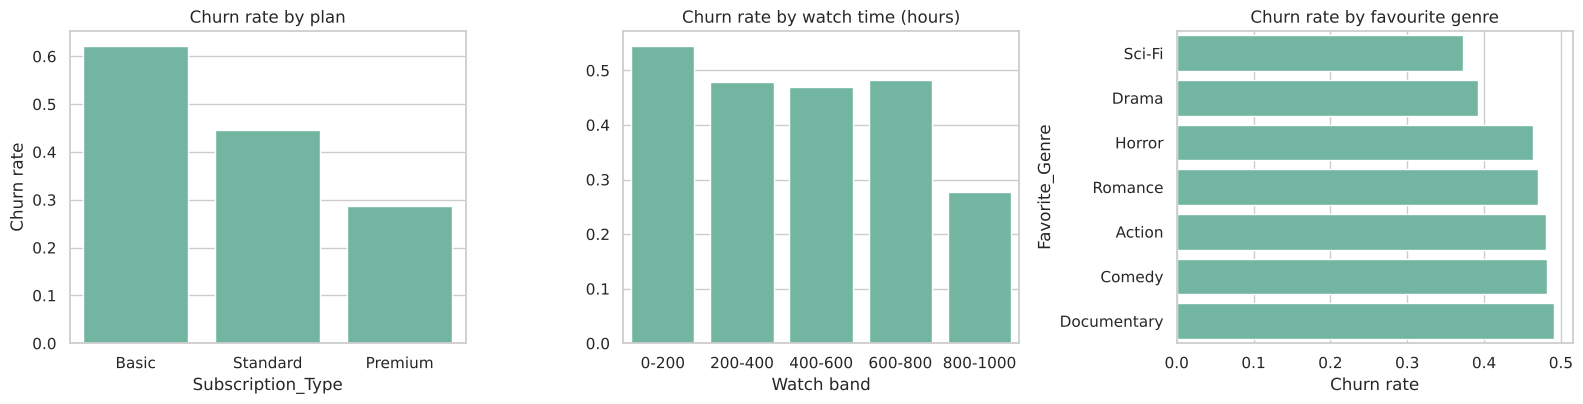

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
order = ['Basic','Standard','Premium']
sns.barplot(data=df, x='Subscription_Type', y='Churn', order=order, ax=ax[0], errorbar=None)
ax[0].set_title('Churn rate by plan'); ax[0].set_ylabel('Churn rate')
df['Watch band'] = pd.cut(df.Watch_Time_Hours, [0,200,400,600,800,1000], labels=['0-200','200-400','400-600','600-800','800-1000'])
sns.barplot(data=df, x='Watch band', y='Churn', ax=ax[1], errorbar=None); ax[1].set_title('Churn rate by watch time (hours)'); ax[1].set_ylabel('')
g = df.groupby('Favorite_Genre').Churn.mean().sort_values()
sns.barplot(x=g.values, y=g.index, ax=ax[2]); ax[2].set_title('Churn rate by favourite genre'); ax[2].set_xlabel('Churn rate')
plt.tight_layout(); plt.savefig('../reports/plots/churn_drivers.png', dpi=130, bbox_inches='tight'); plt.show()
df = df.drop(columns='Watch band')

## 3. Train/test split and models

- **Stratified** 80/20 split, so both sets keep the 45% churn rate.
- **Baselines:** majority class, and Logistic Regression.
- **Class imbalance:** handled with `class_weight='balanced'` / `scale_pos_weight`.
- **5-fold stratified cross-validation** on the training set for model selection. The test set is used once at the end.

In [6]:
X = df[cat + num]; y = df.Churn
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)
spw = (y_tr==0).sum() / (y_tr==1).sum()
models = {
    'Majority baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(400, min_samples_leaf=10, class_weight='balanced', n_jobs=-1, random_state=RS),
    'XGBoost': XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
                             scale_pos_weight=spw, eval_metric='logloss', random_state=RS, n_jobs=-1),
}
rows = []
for name, m in models.items():
    s = cross_validate(Pipeline([('pre', pre), ('m', m)]), X_tr, y_tr, cv=cv,
                       scoring=['roc_auc','average_precision','f1','balanced_accuracy'])
    rows.append({'Model': name, **{k.replace('test_',''): s[k].mean() for k in s if k.startswith('test_')}})
cv_res = pd.DataFrame(rows).set_index('Model').round(3)
cv_res

,roc_auc,average_precision,f1,balanced_accuracy
Model,,,,
Majority baseline,0.500,0.451,0.000,0.500
Logistic Regression,0.689,0.629,0.612,0.638
Random Forest,0.694,0.634,0.618,0.641
XGBoost,0.698,0.644,0.627,0.649


## 4. Final evaluation on the held-out test set

In [7]:
fitted, test_rows = {}, []
for name, m in models.items():
    p = Pipeline([('pre', pre), ('m', m)]).fit(X_tr, y_tr); fitted[name] = p
    prob = p.predict_proba(X_te)[:, 1]; pred = (prob >= 0.5).astype(int)
    test_rows.append({'Model': name, 'ROC-AUC': roc_auc_score(y_te, prob), 'PR-AUC': average_precision_score(y_te, prob),
                      'Accuracy': accuracy_score(y_te, pred), 'Precision': precision_score(y_te, pred, zero_division=0),
                      'Recall': recall_score(y_te, pred), 'F1': f1_score(y_te, pred),
                      'Balanced acc.': balanced_accuracy_score(y_te, pred)})
test_res = pd.DataFrame(test_rows).set_index('Model').round(3)
test_res.to_csv('../reports/test_metrics.csv'); test_res

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,Balanced acc.
Model,,,,,,,
Majority baseline,0.500,0.451,0.549,0.000,0.000,0.000,0.500
Logistic Regression,0.683,0.626,0.639,0.594,0.636,0.614,0.639
Random Forest,0.680,0.629,0.627,0.578,0.640,0.608,0.628
XGBoost,0.686,0.634,0.638,0.588,0.658,0.621,0.640


Best model by ROC-AUC: XGBoost


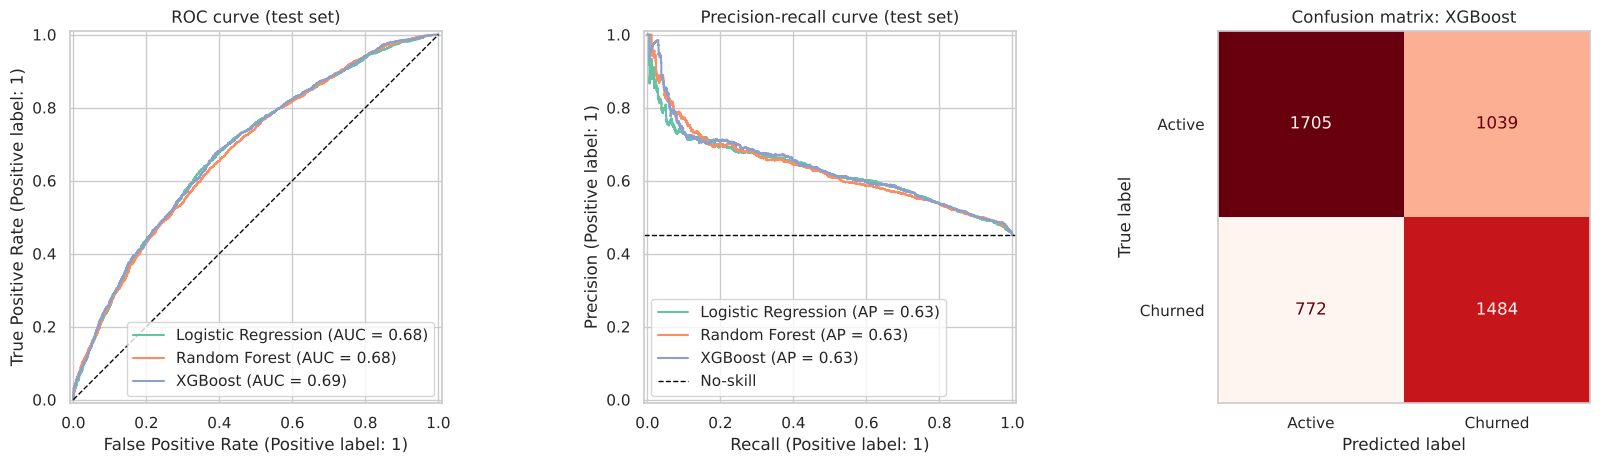

In [8]:
best_name = test_res.drop('Majority baseline')['ROC-AUC'].idxmax(); best = fitted[best_name]
print('Best model by ROC-AUC:', best_name)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
for n in ['Logistic Regression','Random Forest','XGBoost']:
    RocCurveDisplay.from_estimator(fitted[n], X_te, y_te, ax=ax[0], name=n)
    PrecisionRecallDisplay.from_estimator(fitted[n], X_te, y_te, ax=ax[1], name=n)
ax[0].plot([0,1],[0,1],'k--',lw=1); ax[0].set_title('ROC curve (test set)')
ax[1].axhline(y_te.mean(), color='k', ls='--', lw=1, label='No-skill'); ax[1].set_title('Precision-recall curve (test set)'); ax[1].legend(loc='lower left')
ConfusionMatrixDisplay.from_estimator(best, X_te, y_te, ax=ax[2], display_labels=['Active','Churned'], cmap='Reds', colorbar=False)
ax[2].set_title(f'Confusion matrix: {best_name}'); ax[2].grid(False)
plt.tight_layout(); plt.savefig('../reports/plots/model_evaluation.png', dpi=130, bbox_inches='tight'); plt.show()

### Choosing a decision threshold

A retention team usually prefers catching more churners (recall) at an acceptable precision. Instead of the default 0.5, I pick the threshold that maximises F1 on the training data's cross-validated predictions, then report it on the test set.

In [9]:
from sklearn.model_selection import cross_val_predict
oof = cross_val_predict(Pipeline([('pre', pre), ('m', models[best_name])]), X_tr, y_tr, cv=cv, method='predict_proba')[:, 1]
ths = np.linspace(0.2, 0.8, 61); f1s = [f1_score(y_tr, (oof >= t).astype(int)) for t in ths]
t_best = ths[int(np.argmax(f1s))]
prob = best.predict_proba(X_te)[:, 1]; pred = (prob >= t_best).astype(int)
print(f"Chosen threshold: {t_best:.2f}")
print(f"Test at tuned threshold -> precision {precision_score(y_te,pred):.3f} | recall {recall_score(y_te,pred):.3f} | F1 {f1_score(y_te,pred):.3f}")

Chosen threshold: 0.35
Test at tuned threshold -> precision 0.516 | recall 0.867 | F1 0.647


## 5. What drives churn? (permutation importance)

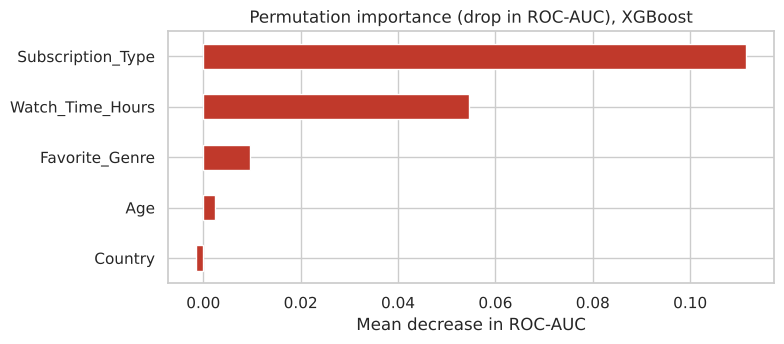

Subscription_Type    0.1116
Watch_Time_Hours     0.0545
Favorite_Genre       0.0097
Age                  0.0025
Country             -0.0015
dtype: float64

In [10]:
pi = permutation_importance(best, X_te, y_te, scoring='roc_auc', n_repeats=10, random_state=RS, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_te.columns).sort_values()
ax = imp.plot.barh(figsize=(8, 3.6), color='#c0392b'); ax.set_title(f'Permutation importance (drop in ROC-AUC), {best_name}')
ax.set_xlabel('Mean decrease in ROC-AUC'); plt.tight_layout()
plt.savefig('../reports/plots/feature_importance.png', dpi=130, bbox_inches='tight'); plt.show()
imp.sort_values(ascending=False).round(4)

In [11]:
import joblib
os.makedirs('../models', exist_ok=True)
joblib.dump({'pipeline': best, 'threshold': float(t_best), 'features': list(X.columns)}, '../models/churn_model.joblib')
print('Saved models/churn_model.joblib')

Saved models/churn_model.joblib


## 6. Conclusions

- The **v1 model was not a real result**. Its label depended only on the login date, so the features had no signal and the model predicted "churn" for everyone. Baselines and ROC-AUC expose this immediately.
- With a label that features *can* explain, the tuned models beat the majority baseline on every threshold-free metric (see the tables above).
- **Subscription plan** is the strongest driver: Basic subscribers churn about twice as often as Premium. **Watch time** and **favourite genre** follow. Age and country add almost nothing.

**Retention ideas:** target Basic-plan customers with upgrade offers, re-engage low-watch-time users with personalised recommendations, and monitor genres with higher churn for content gaps.

**Limitations:** the data is synthetic and the churn label is simulated, so absolute scores won't transfer to a real service. The point of the project is a sound, honest modelling workflow.